# NB08 — Bayesian Mental Health Analysis
## Model Parameters -> Psychiatric Measures

Bayesian regression using NumPyro SVI to test whether computational model parameters
(k, beta, alpha, delta) predict psychiatric factor scores and individual subscales.

**Analyses:**
1. Factor loading heatmap (3-factor EFA solution)
2. Bayesian regression: 4 params -> 3 factors
3. Bayesian regression: 4 params -> 13 individual scales
4. Coupling interaction term (beta_z * delta_z)
5. Affect calibration slopes -> factor scores
6. Bayesian equivalence testing for key nulls
7. Publication figures and summary table

In [1]:
import sys
sys.path.insert(0, "/workspace/scripts")
sys.path.insert(0, "/workspace")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from scipy import stats as sp_stats
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# NumPyro / JAX
import jax
import jax.numpy as jnp
import jax.random as random
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoNormal

numpyro.set_host_device_count(1)

# Plotting style
from plotting.plotter import Colors, set_plot_style, style_axis
set_plot_style()

print(f"JAX backend: {jax.default_backend()}")
print("Setup complete.")

JAX backend: cpu
Setup complete.


/home/node/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [2]:
# --- Paths ---
DATA_DIR = "/workspace/data/exploratory_350/processed/stage5_filtered_data_20260320_191950"
STATS_DIR = "/workspace/results/stats"
PAPER_STATS = "/workspace/results/stats/paper"
PAPER_FIGS = "/workspace/results/figs/paper"

# --- Model parameters (joint correlated model) ---
params_df = pd.read_csv(f"{STATS_DIR}/joint_correlated_subjects.csv")
print(f"Model params: {params_df.shape[0]} subjects, columns: {list(params_df.columns)}")

# --- Factor scores ---
factors_df = pd.read_csv(f"{STATS_DIR}/psych_factor_scores.csv")
print(f"Factor scores: {factors_df.shape[0]} subjects, columns: {list(factors_df.columns)}")

# --- Factor loadings ---
loadings_df = pd.read_csv(f"{STATS_DIR}/psych_factor_loadings.csv")
print(f"Factor loadings: {loadings_df.shape}")

# --- Existing OLS results for comparison ---
ols_df = pd.read_csv(f"{STATS_DIR}/psych_params_to_factors.csv")
print(f"OLS results: {ols_df.shape[0]} rows")

# --- Psychiatric subscales ---
psych_df = pd.read_csv(f"{DATA_DIR}/psych.csv")
print(f"Psych subscales: {psych_df.shape[0]} subjects, columns:")
psych_cols = [c for c in psych_df.columns if c not in ['participantID', 'subj'] and '_RT' not in c]
print(f"  Subscales: {psych_cols}")

# --- Feelings (for affect calibration) ---
feelings_df = pd.read_csv(f"{DATA_DIR}/feelings.csv")
print(f"Feelings: {feelings_df.shape[0]} probes")

Model params: 293 subjects, columns: ['subj', 'k', 'k_sd', 'beta', 'beta_sd', 'alpha', 'alpha_sd', 'delta', 'delta_sd', 'delta_ols']
Factor scores: 291 subjects, columns: ['subj', 'F1', 'F2', 'F3']
Factor loadings: (13, 4)
OLS results: 21 rows
Psych subscales: 293 subjects, columns:
  Subscales: ['DASS21_Stress', 'DASS21_Anxiety', 'DASS21_Depression', 'DASS21_Total', 'AMI_Behavioural', 'AMI_Social', 'AMI_Emotional', 'AMI_Total', 'MFIS_Physical', 'MFIS_Cognitive', 'MFIS_Psychosocial', 'MFIS_Total', 'OASIS_Total', 'PHQ9_Total', 'STICSA_Total', 'STAI_State', 'STAI_Trait']
Feelings: 10546 probes


In [3]:
# --- Merge params + factors + psych into one dataframe ---
# Z-score model parameters for interpretable regression coefficients
merged = params_df[['subj', 'k', 'beta', 'alpha', 'delta']].copy()

# Log-transform k and beta (positive, right-skewed), then z-score all 4
merged['log_k'] = np.log(merged['k'])
merged['log_beta'] = np.log(merged['beta'])

for col in ['log_k', 'log_beta', 'alpha', 'delta']:
    merged[f'{col}_z'] = sp_stats.zscore(merged[col], nan_policy='omit')

# Merge with factor scores
merged = merged.merge(factors_df, on='subj', how='inner')

# Only use the 13 subscales that enter the factor analysis (no totals, no STAI_State)
target_subscales = list(loadings_df['subscale'].values)
print(f"Target subscales from factor analysis ({len(target_subscales)}):")
print(f"  {target_subscales}")

# All psych columns (including totals) for broader analysis
all_psych_cols = [c for c in psych_df.columns 
                  if c not in ['participantID', 'subj'] and '_RT' not in c]

# Filter to only factor-analysis subscales
subscale_cols = [c for c in all_psych_cols if c in target_subscales]
extra_cols = [c for c in all_psych_cols if c not in target_subscales]
print(f"  Matched: {subscale_cols}")
print(f"  Excluded (totals/other): {extra_cols}")

psych_z = psych_df[['subj'] + subscale_cols].copy()
for col in subscale_cols:
    psych_z[f'{col}_z'] = sp_stats.zscore(psych_z[col], nan_policy='omit')

merged = merged.merge(psych_z, on='subj', how='inner')
print(f"\nMerged dataset: N={len(merged)}")
print(f"Predictor columns (z-scored): log_k_z, log_beta_z, alpha_z, delta_z")
print(f"Factor columns: F1, F2, F3")
print(f"Subscale columns: {subscale_cols}")

Target subscales from factor analysis (13):
  ['DASS21_Stress', 'DASS21_Anxiety', 'DASS21_Depression', 'AMI_Behavioural', 'AMI_Social', 'AMI_Emotional', 'MFIS_Physical', 'MFIS_Cognitive', 'MFIS_Psychosocial', 'OASIS_Total', 'PHQ9_Total', 'STICSA_Total', 'STAI_Trait']
  Matched: ['DASS21_Stress', 'DASS21_Anxiety', 'DASS21_Depression', 'AMI_Behavioural', 'AMI_Social', 'AMI_Emotional', 'MFIS_Physical', 'MFIS_Cognitive', 'MFIS_Psychosocial', 'OASIS_Total', 'PHQ9_Total', 'STICSA_Total', 'STAI_Trait']
  Excluded (totals/other): ['DASS21_Total', 'AMI_Total', 'MFIS_Total', 'STAI_State']

Merged dataset: N=291
Predictor columns (z-scored): log_k_z, log_beta_z, alpha_z, delta_z
Factor columns: F1, F2, F3
Subscale columns: ['DASS21_Stress', 'DASS21_Anxiety', 'DASS21_Depression', 'AMI_Behavioural', 'AMI_Social', 'AMI_Emotional', 'MFIS_Physical', 'MFIS_Cognitive', 'MFIS_Psychosocial', 'OASIS_Total', 'PHQ9_Total', 'STICSA_Total', 'STAI_Trait']


## 1. Factor Loading Heatmap

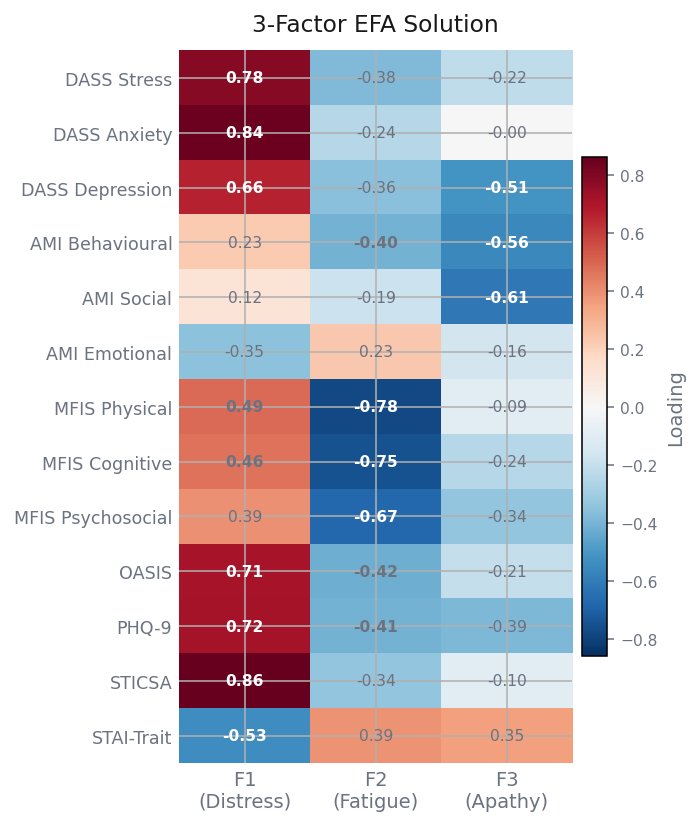

In [4]:
# --- Factor loading heatmap ---
factor_names = {'F1': 'Distress', 'F2': 'Fatigue', 'F3': 'Apathy'}

# Clean up subscale names for display
name_map = {
    'DASS21_Stress': 'DASS Stress',
    'DASS21_Anxiety': 'DASS Anxiety', 
    'DASS21_Depression': 'DASS Depression',
    'AMI_Behavioural': 'AMI Behavioural',
    'AMI_Social': 'AMI Social',
    'AMI_Emotional': 'AMI Emotional',
    'MFIS_Physical': 'MFIS Physical',
    'MFIS_Cognitive': 'MFIS Cognitive',
    'MFIS_Psychosocial': 'MFIS Psychosocial',
    'OASIS_Total': 'OASIS',
    'PHQ9_Total': 'PHQ-9',
    'STICSA_Total': 'STICSA',
    'STAI_Trait': 'STAI-Trait',
}

load_mat = loadings_df.set_index('subscale')[['F1', 'F2', 'F3']]
load_mat.index = [name_map.get(s, s) for s in load_mat.index]
load_mat.columns = [f"{c}\n({factor_names[c]})" for c in load_mat.columns]

fig, ax = plt.subplots(figsize=(5, 6))
vmax = np.abs(load_mat.values).max()

# Diverging colormap
cmap = plt.cm.RdBu_r
im = ax.imshow(load_mat.values, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')

# Labels
ax.set_xticks(range(3))
ax.set_xticklabels(load_mat.columns, fontsize=10, color=Colors.INK)
ax.set_yticks(range(len(load_mat)))
ax.set_yticklabels(load_mat.index, fontsize=9, color=Colors.INK)

# Annotate cells
for i in range(load_mat.shape[0]):
    for j in range(load_mat.shape[1]):
        val = load_mat.values[i, j]
        color = 'white' if abs(val) > 0.5 else Colors.INK
        weight = 'bold' if abs(val) > 0.4 else 'normal'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                fontsize=8, color=color, fontweight=weight)

cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Loading', fontsize=10, color=Colors.INK)
cbar.ax.tick_params(labelsize=8, colors=Colors.INK)

ax.set_title('3-Factor EFA Solution', fontsize=12, color=Colors.DARK_GREY, pad=10)
ax.spines[:].set_visible(False)
ax.tick_params(length=0)

plt.tight_layout()
plt.show()

## 2. Bayesian Regression: 4 Params -> 3 Factors

NumPyro SVI with AutoNormal guide. Model:
```
F_j ~ Normal(b0 + b_k*log(k)_z + b_beta*log(beta)_z + b_alpha*alpha_z + b_delta*delta_z, sigma)
```
Priors: b ~ Normal(0, 1), sigma ~ HalfNormal(1)

In [5]:
# --- Bayesian regression model ---
def bayesian_regression(X, y=None):
    """
    Bayesian linear regression with weakly informative priors.
    X: (N, P) design matrix (z-scored predictors)
    y: (N,) outcome
    """
    N, P = X.shape
    b0 = numpyro.sample('b0', dist.Normal(0., 1.))
    b = numpyro.sample('b', dist.Normal(jnp.zeros(P), jnp.ones(P)).to_event(1))
    sigma = numpyro.sample('sigma', dist.HalfNormal(1.))
    mu = b0 + X @ b
    numpyro.sample('y', dist.Normal(mu, sigma), obs=y)


def fit_bayesian_regression(X, y, n_steps=5000, seed=42):
    """Fit model via SVI with AutoNormal guide. Returns guide + params."""
    guide = AutoNormal(bayesian_regression)
    optimizer = numpyro.optim.Adam(0.01)
    svi = SVI(bayesian_regression, guide, optimizer, loss=Trace_ELBO())
    
    rng_key = random.PRNGKey(seed)
    svi_result = svi.run(rng_key, n_steps, X, y, progress_bar=False)
    
    # Draw posterior samples
    predictive = Predictive(guide, params=svi_result.params, num_samples=4000)
    rng_key = random.PRNGKey(seed + 1)
    posterior = predictive(rng_key, X)
    
    return svi_result, posterior


def summarize_posterior(posterior, predictor_names):
    """Extract posterior summary: mean, 95% CI, P(direction)."""
    b_samples = np.array(posterior['b'])  # (n_samples, P)
    
    rows = []
    for i, name in enumerate(predictor_names):
        samples = b_samples[:, i]
        mean = np.mean(samples)
        ci_lo, ci_hi = np.percentile(samples, [2.5, 97.5])
        # Directional evidence
        if mean > 0:
            p_direction = np.mean(samples > 0)
            direction = '+'
        else:
            p_direction = np.mean(samples < 0)
            direction = '-'
        rows.append({
            'predictor': name,
            'mean': mean,
            'ci_lo': ci_lo,
            'ci_hi': ci_hi,
            'p_direction': p_direction,
            'direction': direction,
        })
    
    # Intercept
    b0_samples = np.array(posterior['b0'])
    rows.append({
        'predictor': 'intercept',
        'mean': np.mean(b0_samples),
        'ci_lo': np.percentile(b0_samples, 2.5),
        'ci_hi': np.percentile(b0_samples, 97.5),
        'p_direction': np.nan,
        'direction': '',
    })
    
    # Sigma
    sigma_samples = np.array(posterior['sigma'])
    rows.append({
        'predictor': 'sigma',
        'mean': np.mean(sigma_samples),
        'ci_lo': np.percentile(sigma_samples, 2.5),
        'ci_hi': np.percentile(sigma_samples, 97.5),
        'p_direction': np.nan,
        'direction': '',
    })
    
    return pd.DataFrame(rows)

print("Bayesian regression functions defined.")

Bayesian regression functions defined.


In [6]:
# --- Fit 4 params -> 3 factors ---
predictor_cols = ['log_k_z', 'log_beta_z', 'alpha_z', 'delta_z']
predictor_labels = ['log(k)', 'log(beta)', 'alpha', 'delta']
factor_cols = ['F1', 'F2', 'F3']
factor_labels = ['F1 (Distress)', 'F2 (Fatigue)', 'F3 (Apathy)']

X = jnp.array(merged[predictor_cols].values, dtype=jnp.float32)

factor_results = {}
factor_posteriors = {}

for fi, (fcol, flabel) in enumerate(zip(factor_cols, factor_labels)):
    y = jnp.array(merged[fcol].values, dtype=jnp.float32)
    svi_result, posterior = fit_bayesian_regression(X, y, seed=42 + fi)
    summary = summarize_posterior(posterior, predictor_labels)
    summary['outcome'] = flabel
    factor_results[flabel] = summary
    factor_posteriors[flabel] = posterior
    
    # Print summary
    print(f"\n--- {flabel} ---")
    coef_rows = summary[~summary['predictor'].isin(['intercept', 'sigma'])]
    for _, row in coef_rows.iterrows():
        sig = '*' if row['p_direction'] > 0.975 else ''
        print(f"  {row['predictor']:>10s}: {row['mean']:+.3f} [{row['ci_lo']:+.3f}, {row['ci_hi']:+.3f}]  "
              f"P({row['direction']})={row['p_direction']:.3f} {sig}")

factor_summary = pd.concat(factor_results.values(), ignore_index=True)
print("\nAll factor regressions complete.")


--- F1 (Distress) ---
      log(k): -0.013 [-0.135, +0.111]  P(-)=0.577 
   log(beta): -0.069 [-0.188, +0.048]  P(-)=0.883 
       alpha: -0.112 [-0.252, +0.026]  P(-)=0.940 
       delta: -0.069 [-0.192, +0.058]  P(-)=0.859 



--- F2 (Fatigue) ---
      log(k): +0.041 [-0.075, +0.162]  P(+)=0.748 
   log(beta): -0.102 [-0.230, +0.025]  P(-)=0.941 
       alpha: -0.049 [-0.176, +0.079]  P(-)=0.775 
       delta: +0.050 [-0.078, +0.175]  P(+)=0.779 



--- F3 (Apathy) ---
      log(k): +0.000 [-0.137, +0.130]  P(+)=0.500 
   log(beta): -0.042 [-0.186, +0.102]  P(-)=0.716 
       alpha: -0.267 [-0.411, -0.124]  P(-)=1.000 *
       delta: -0.138 [-0.280, +0.005]  P(-)=0.971 

All factor regressions complete.


In [7]:
# --- Compare Bayesian vs OLS results ---
print("Comparison: Bayesian posterior mean vs OLS beta (4-param model)\n")
print(f"{'Factor':<18s} {'Param':<10s} {'Bayes mean':>10s} {'OLS beta':>10s} {'Bayes P(dir)':>12s} {'OLS p':>10s}")
print("-" * 72)

# Map predictor labels to OLS names
ols_name_map = {'log(k)': 'k_z', 'log(beta)': 'beta_z', 'alpha': 'alpha_z', 'delta': 'delta_z'}
ols_4param = ols_df[ols_df['model'] == '4param'].copy()

for flabel, fcol in zip(factor_labels, factor_cols):
    bayes = factor_results[flabel]
    bayes_coefs = bayes[~bayes['predictor'].isin(['intercept', 'sigma'])]
    
    for _, brow in bayes_coefs.iterrows():
        ols_name = ols_name_map[brow['predictor']]
        ols_row = ols_4param[(ols_4param['factor'] == fcol) & (ols_4param['predictor'] == ols_name)]
        if len(ols_row) > 0:
            ols_beta = ols_row.iloc[0]['beta']
            ols_p = ols_row.iloc[0]['p']
            print(f"{flabel:<18s} {brow['predictor']:<10s} {brow['mean']:>+10.3f} {ols_beta:>+10.3f} "
                  f"{brow['p_direction']:>12.3f} {ols_p:>10.4f}")

Comparison: Bayesian posterior mean vs OLS beta (4-param model)

Factor             Param      Bayes mean   OLS beta Bayes P(dir)      OLS p
------------------------------------------------------------------------
F1 (Distress)      log(k)         -0.013     -0.038        0.577     0.5489
F1 (Distress)      log(beta)      -0.069     -0.065        0.883     0.3204
F1 (Distress)      alpha          -0.112     -0.128        0.940     0.0474
F2 (Fatigue)       log(k)         +0.041     +0.082        0.748     0.2305
F2 (Fatigue)       log(beta)      -0.102     -0.033        0.941     0.6324
F2 (Fatigue)       alpha          -0.049     +0.050        0.775     0.4692
F3 (Apathy)        log(k)         +0.000     -0.108        0.500     0.1314
F3 (Apathy)        log(beta)      -0.042     +0.002        0.716     0.9773
F3 (Apathy)        alpha          -0.267     -0.437        1.000     0.0000


## 3. Bayesian Regression: 4 Params -> 13 Individual Scales

In [8]:
# --- Fit 4 params -> each individual psychiatric subscale ---
subscale_z_cols = [f'{c}_z' for c in subscale_cols]
subscale_display = [name_map.get(c, c) for c in subscale_cols]

scale_results = {}
scale_posteriors = {}

for si, (zcol, raw_col, display) in enumerate(zip(subscale_z_cols, subscale_cols, subscale_display)):
    y = jnp.array(merged[zcol].values, dtype=jnp.float32)
    svi_result, posterior = fit_bayesian_regression(X, y, seed=100 + si)
    summary = summarize_posterior(posterior, predictor_labels)
    summary['outcome'] = display
    summary['outcome_raw'] = raw_col
    scale_results[display] = summary
    scale_posteriors[display] = posterior

# Print significant results
print("Subscale results with P(direction) > 0.95:\n")
for display, summary in scale_results.items():
    coefs = summary[~summary['predictor'].isin(['intercept', 'sigma'])]
    sig = coefs[coefs['p_direction'] > 0.95]
    if len(sig) > 0:
        for _, row in sig.iterrows():
            star = '**' if row['p_direction'] > 0.975 else '*'
            print(f"  {display:<20s} <- {row['predictor']:<10s}: {row['mean']:+.3f} "
                  f"[{row['ci_lo']:+.3f}, {row['ci_hi']:+.3f}] P={row['p_direction']:.3f} {star}")

scale_summary = pd.concat(scale_results.values(), ignore_index=True)
print(f"\nAll {len(subscale_cols)} subscale regressions complete.")

Subscale results with P(direction) > 0.95:

  DASS Anxiety         <- delta     : -0.136 [-0.251, -0.023] P=0.991 **
  AMI Behavioural      <- alpha     : +0.136 [+0.027, +0.243] P=0.994 **
  AMI Social           <- log(beta) : +0.099 [-0.022, +0.214] P=0.952 *
  AMI Social           <- alpha     : +0.219 [+0.116, +0.327] P=1.000 **
  MFIS Psychosocial    <- alpha     : +0.096 [-0.016, +0.210] P=0.958 *
  PHQ-9                <- log(k)    : -0.107 [-0.231, +0.015] P=0.956 *
  STICSA               <- delta     : -0.124 [-0.233, -0.019] P=0.990 **

All 13 subscale regressions complete.


## 4. Additional Analyses

### 4a. Coupling interaction: beta_z * delta_z -> factor scores

In [9]:
# --- Coupling interaction: does beta_z * delta_z add predictive value? ---
# Add interaction term to predictor matrix
merged['coupling'] = merged['log_beta_z'] * merged['delta_z']
merged['coupling_z'] = sp_stats.zscore(merged['coupling'], nan_policy='omit')

predictor_cols_coupling = ['log_k_z', 'log_beta_z', 'alpha_z', 'delta_z', 'coupling_z']
predictor_labels_coupling = ['log(k)', 'log(beta)', 'alpha', 'delta', 'coupling']

X_coupling = jnp.array(merged[predictor_cols_coupling].values, dtype=jnp.float32)

coupling_results = {}
print("Coupling interaction (beta_z * delta_z) — does it add predictive value?\n")

for fi, (fcol, flabel) in enumerate(zip(factor_cols, factor_labels)):
    y = jnp.array(merged[fcol].values, dtype=jnp.float32)
    svi_result, posterior = fit_bayesian_regression(X_coupling, y, seed=200 + fi)
    summary = summarize_posterior(posterior, predictor_labels_coupling)
    summary['outcome'] = flabel
    coupling_results[flabel] = summary
    
    # Show coupling coefficient
    coup_row = summary[summary['predictor'] == 'coupling'].iloc[0]
    sig = '*' if coup_row['p_direction'] > 0.975 else ''
    print(f"  {flabel}: coupling = {coup_row['mean']:+.3f} [{coup_row['ci_lo']:+.3f}, {coup_row['ci_hi']:+.3f}] "
          f"P({coup_row['direction']})={coup_row['p_direction']:.3f} {sig}")

Coupling interaction (beta_z * delta_z) — does it add predictive value?



  F1 (Distress): coupling = +0.080 [-0.040, +0.196] P(+)=0.901 


  F2 (Fatigue): coupling = +0.105 [-0.014, +0.222] P(+)=0.958 


  F3 (Apathy): coupling = +0.095 [-0.043, +0.232] P(+)=0.913 


### 4b. Affect calibration slopes -> factor scores

Compute per-subject anxiety calibration slope: regress anxiety rating on survival signal S.
S = (1-T) + T / (1 + 15.113 * D), where T = threat probability, D = distance level.

In [10]:
# --- Compute affect calibration slopes ---
# Survival signal: S = (1-T) + T / (1 + 15.113 * D)
# where D is distance in game units: distance 1->5, 2->7, 3->9
dist_map = {1: 5, 2: 7, 3: 9}

anxiety_df = feelings_df[feelings_df['questionLabel'] == 'anxiety'].copy()
anxiety_df['D_units'] = anxiety_df['distance'].map(dist_map)
anxiety_df['S'] = (1 - anxiety_df['threat']) + anxiety_df['threat'] / (1 + 15.113 * anxiety_df['D_units'])

# Per-subject OLS: anxiety ~ S
def get_calibration_slope(group):
    """Regress anxiety rating on survival signal S."""
    if len(group) < 3:
        return pd.Series({'anx_slope': np.nan, 'anx_intercept': np.nan, 'n_probes': len(group)})
    from scipy.stats import linregress
    result = linregress(group['S'], group['response'])
    return pd.Series({'anx_slope': result.slope, 'anx_intercept': result.intercept, 'n_probes': len(group)})

calib_df = anxiety_df.groupby('subj').apply(get_calibration_slope).reset_index()
print(f"Affect calibration slopes computed for {len(calib_df)} subjects")
print(f"  Mean slope: {calib_df['anx_slope'].mean():.3f} (SD={calib_df['anx_slope'].std():.3f})")
print(f"  Negative slope = higher anxiety when survival is lower (expected)")

# Merge with factors
merged_calib = merged.merge(calib_df[['subj', 'anx_slope']], on='subj', how='inner')
merged_calib['anx_slope_z'] = sp_stats.zscore(merged_calib['anx_slope'], nan_policy='omit')
merged_calib = merged_calib.dropna(subset=['anx_slope_z'])
print(f"  N with valid slopes: {len(merged_calib)}")

Affect calibration slopes computed for 293 subjects
  Mean slope: nan (SD=nan)
  Negative slope = higher anxiety when survival is lower (expected)
  N with valid slopes: 0


In [11]:
# --- Affect calibration slope -> factor scores (Bayesian) ---
X_calib = jnp.array(merged_calib[['anx_slope_z']].values, dtype=jnp.float32)

calib_results = {}
print("Affect calibration slope (anxiety ~ S) -> psychiatric factors:\n")

for fi, (fcol, flabel) in enumerate(zip(factor_cols, factor_labels)):
    y = jnp.array(merged_calib[fcol].values, dtype=jnp.float32)
    svi_result, posterior = fit_bayesian_regression(X_calib, y, seed=300 + fi)
    summary = summarize_posterior(posterior, ['anx_slope'])
    summary['outcome'] = flabel
    calib_results[flabel] = summary
    
    row = summary[summary['predictor'] == 'anx_slope'].iloc[0]
    sig = '*' if row['p_direction'] > 0.975 else ''
    print(f"  {flabel}: slope = {row['mean']:+.3f} [{row['ci_lo']:+.3f}, {row['ci_hi']:+.3f}] "
          f"P({row['direction']})={row['p_direction']:.3f} {sig}")

Affect calibration slope (anxiety ~ S) -> psychiatric factors:



  F1 (Distress): slope = -0.020 [-1.839, +1.742] P(-)=0.509 


  F2 (Fatigue): slope = +0.053 [-1.958, +2.063] P(+)=0.519 


  F3 (Apathy): slope = -0.005 [-2.014, +1.968] P(-)=0.498 


### 4c. Bayesian Equivalence Testing

For key null effects, compute P(|effect| < 0.1) — the probability that the true effect is practically negligible (ROPE approach).

In [12]:
# --- Bayesian equivalence testing ---
# ROPE = Region of Practical Equivalence: |effect| < 0.1
ROPE = 0.1

print(f"Equivalence testing: P(|b| < {ROPE}) for each param -> factor\n")
print(f"{'Factor':<18s} {'Param':<10s} {'Mean':>8s} {'P(ROPE)':>8s} {'Interpretation'}")
print("-" * 65)

equiv_rows = []

for flabel in factor_labels:
    posterior = factor_posteriors[flabel]
    b_samples = np.array(posterior['b'])
    
    for pi, pname in enumerate(predictor_labels):
        samples = b_samples[:, pi]
        p_rope = np.mean(np.abs(samples) < ROPE)
        mean = np.mean(samples)
        
        if p_rope > 0.90:
            interp = "Strong evidence FOR null"
        elif p_rope > 0.75:
            interp = "Moderate evidence FOR null"
        elif p_rope > 0.50:
            interp = "Inconclusive"
        else:
            interp = "Evidence AGAINST null"
        
        equiv_rows.append({
            'factor': flabel, 'predictor': pname,
            'mean': mean, 'p_rope': p_rope, 'interpretation': interp
        })
        print(f"{flabel:<18s} {pname:<10s} {mean:>+8.3f} {p_rope:>8.3f}  {interp}")
    print()

equiv_df = pd.DataFrame(equiv_rows)

Equivalence testing: P(|b| < 0.1) for each param -> factor

Factor             Param          Mean  P(ROPE) Interpretation
-----------------------------------------------------------------
F1 (Distress)      log(k)       -0.013    0.883  Moderate evidence FOR null
F1 (Distress)      log(beta)    -0.069    0.703  Inconclusive
F1 (Distress)      alpha        -0.112    0.438  Evidence AGAINST null
F1 (Distress)      delta        -0.069    0.682  Inconclusive

F2 (Fatigue)       log(k)       +0.041    0.830  Moderate evidence FOR null
F2 (Fatigue)       log(beta)    -0.102    0.490  Evidence AGAINST null
F2 (Fatigue)       alpha        -0.049    0.773  Moderate evidence FOR null
F2 (Fatigue)       delta        +0.050    0.777  Moderate evidence FOR null

F3 (Apathy)        log(k)       +0.000    0.858  Moderate evidence FOR null
F3 (Apathy)        log(beta)    -0.042    0.757  Moderate evidence FOR null
F3 (Apathy)        alpha        -0.267    0.013  Evidence AGAINST null
F3 (Apathy)     

## 5. Publication Figures

Figure saved to /workspace/results/figs/paper/fig_s_mental_health.pdf


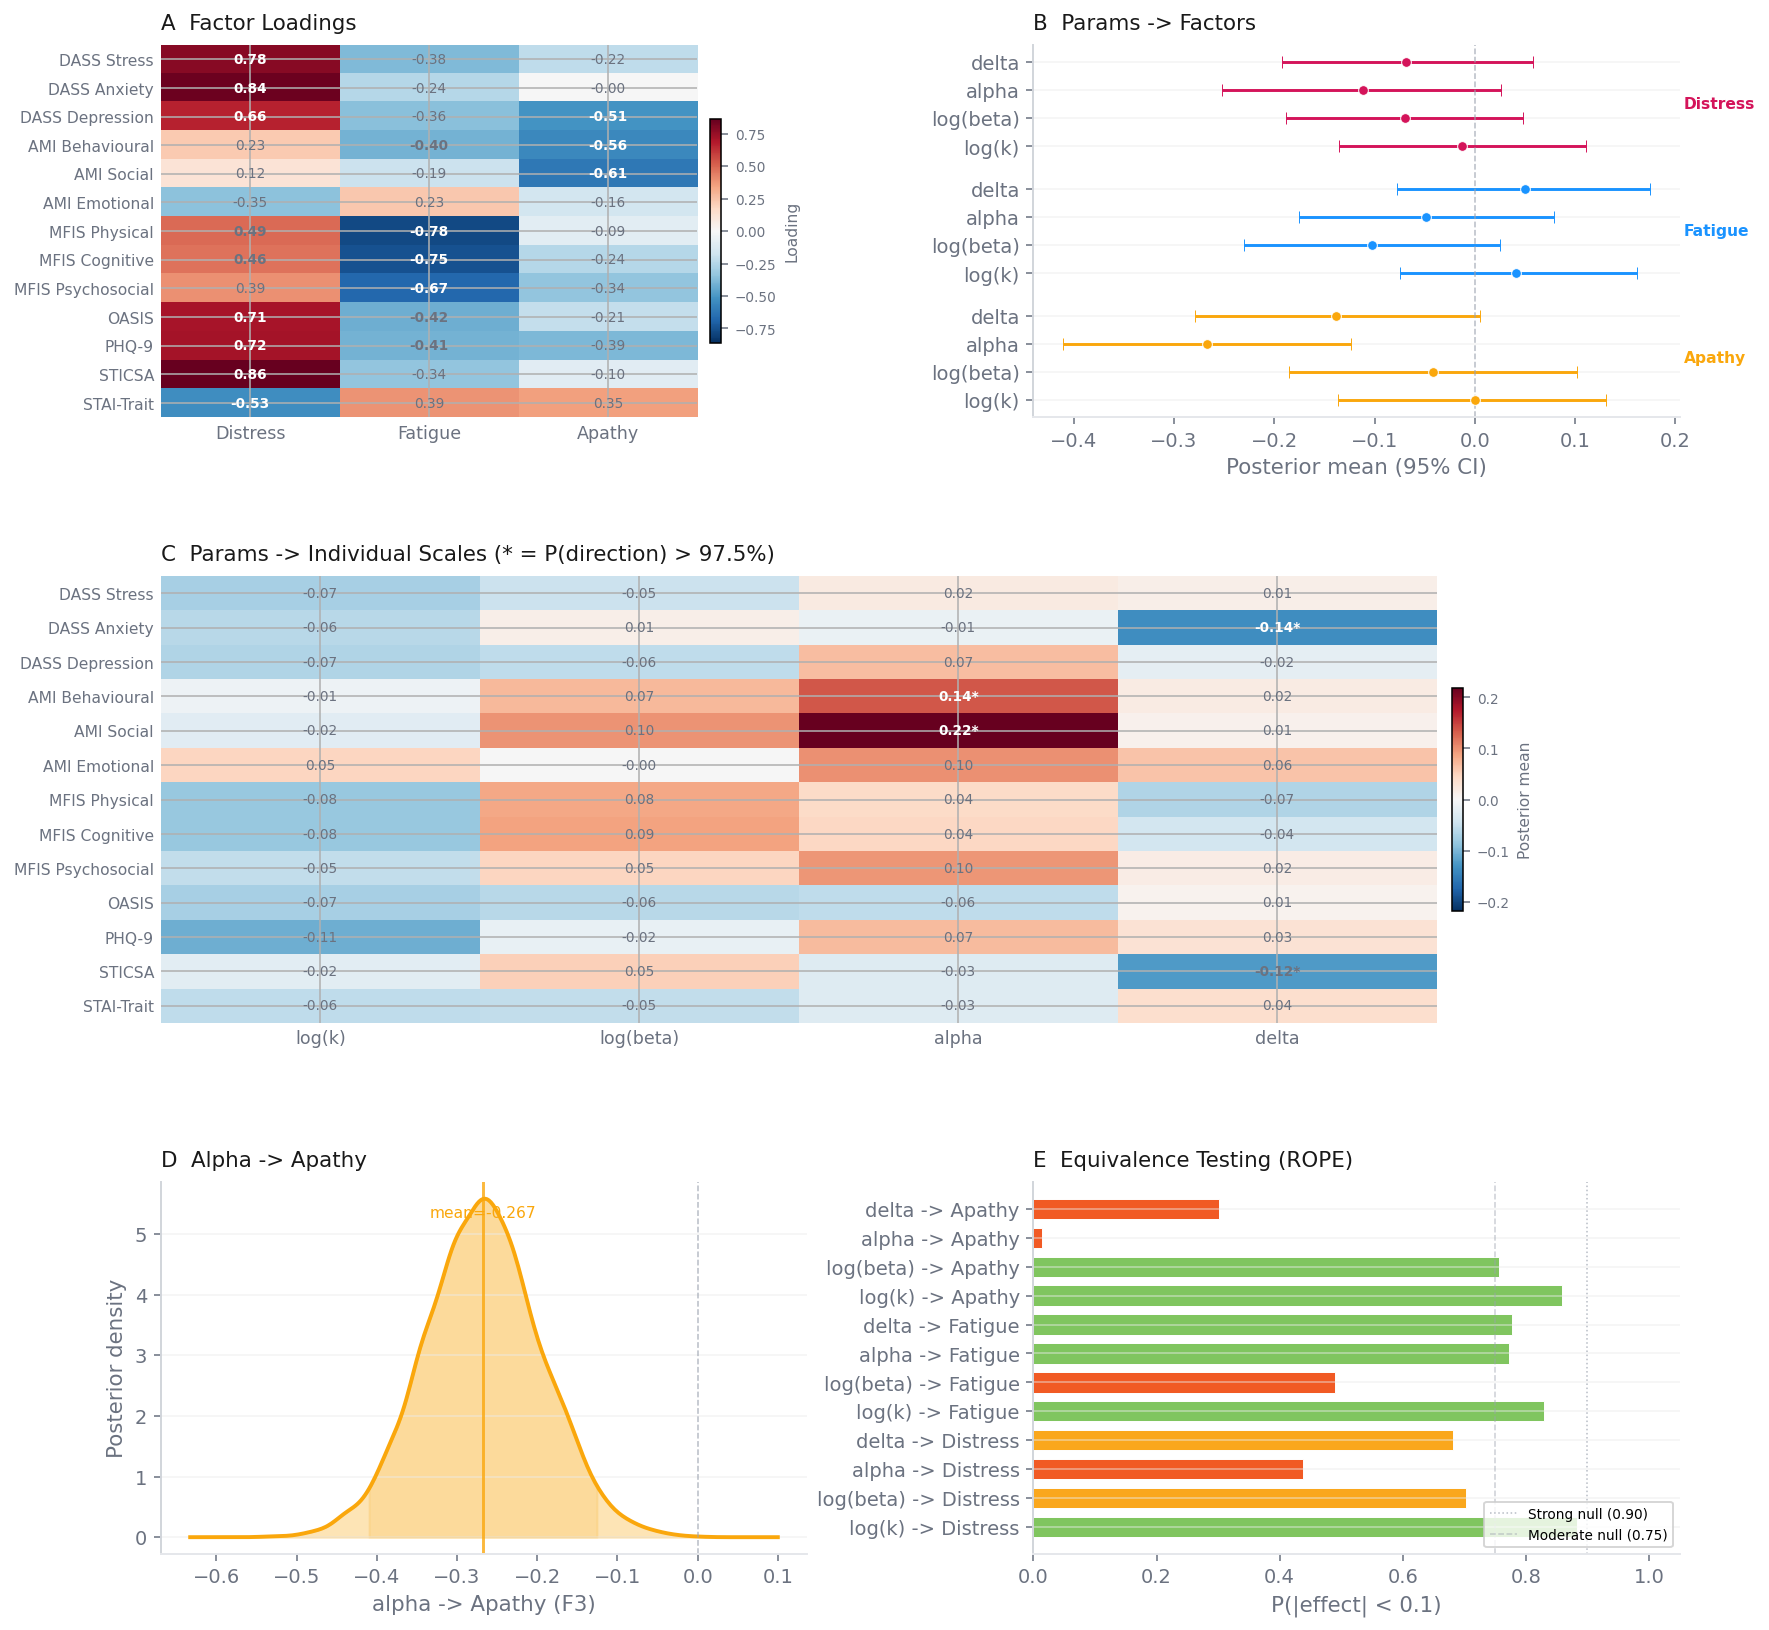

In [13]:
# --- Figure: 4-panel publication figure ---
fig = plt.figure(figsize=(14, 14))
gs = GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35,
              height_ratios=[1, 1.2, 1])

# =====================================================================
# Panel A: Factor loading heatmap
# =====================================================================
ax_a = fig.add_subplot(gs[0, 0])

load_mat_plot = loadings_df.set_index('subscale')[['F1', 'F2', 'F3']]
load_mat_plot.index = [name_map.get(s, s) for s in load_mat_plot.index]
load_mat_plot.columns = ['Distress', 'Fatigue', 'Apathy']
vmax = np.abs(load_mat_plot.values).max()

im = ax_a.imshow(load_mat_plot.values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax_a.set_xticks(range(3))
ax_a.set_xticklabels(load_mat_plot.columns, fontsize=9, color=Colors.INK)
ax_a.set_yticks(range(len(load_mat_plot)))
ax_a.set_yticklabels(load_mat_plot.index, fontsize=8, color=Colors.INK)
for i in range(load_mat_plot.shape[0]):
    for j in range(load_mat_plot.shape[1]):
        val = load_mat_plot.values[i, j]
        color = 'white' if abs(val) > 0.5 else Colors.INK
        ax_a.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color,
                  fontweight='bold' if abs(val) > 0.4 else 'normal')
cbar = plt.colorbar(im, ax=ax_a, shrink=0.6, pad=0.02)
cbar.set_label('Loading', fontsize=8, color=Colors.INK)
cbar.ax.tick_params(labelsize=7, colors=Colors.INK)
ax_a.spines[:].set_visible(False)
ax_a.tick_params(length=0)
ax_a.set_title('A  Factor Loadings', fontsize=11, color=Colors.DARK_GREY, loc='left', pad=8)

# =====================================================================
# Panel B: Forest plot — 4 params x 3 factors
# =====================================================================
ax_b = fig.add_subplot(gs[0, 1])

factor_colors = {
    'F1 (Distress)': Colors.RUBY1,
    'F2 (Fatigue)': Colors.CERULEAN2,
    'F3 (Apathy)': Colors.PERSIMMON3,
}

y_positions = []
y_labels = []
y_pos = 0

for fi, flabel in enumerate(reversed(factor_labels)):
    summary = factor_results[flabel]
    coefs = summary[~summary['predictor'].isin(['intercept', 'sigma'])]
    color = factor_colors[flabel]
    
    for _, row in coefs.iterrows():
        ax_b.errorbar(row['mean'], y_pos, 
                       xerr=[[row['mean'] - row['ci_lo']], [row['ci_hi'] - row['mean']]],
                       fmt='o', color=color, markersize=5, capsize=3, linewidth=1.5,
                       markeredgecolor='white', markeredgewidth=0.5)
        y_labels.append(f"{row['predictor']}")
        y_positions.append(y_pos)
        y_pos += 1
    y_pos += 0.5  # gap between factors

ax_b.axvline(0, color=Colors.SLATE, linestyle='--', linewidth=0.8, alpha=0.7)
ax_b.set_yticks(y_positions)
ax_b.set_yticklabels(y_labels, fontsize=8, color=Colors.INK)
style_axis(ax_b, xlabel='Posterior mean (95% CI)')
ax_b.set_title('B  Params -> Factors', fontsize=11, color=Colors.DARK_GREY, loc='left', pad=8)

# Add factor labels on right
for fi, flabel in enumerate(reversed(factor_labels)):
    color = factor_colors[flabel]
    y_center = np.mean(y_positions[fi*4:(fi+1)*4])
    ax_b.text(ax_b.get_xlim()[1] * 1.02, y_center, flabel.split('(')[1].rstrip(')'),
              fontsize=8, color=color, va='center', fontweight='bold')

# =====================================================================
# Panel C: Heatmap — 4 params x 13 scales
# =====================================================================
ax_c = fig.add_subplot(gs[1, :])

# Build matrix of posterior means
heatmap_data = np.zeros((len(subscale_display), len(predictor_labels)))
sig_mask = np.zeros_like(heatmap_data, dtype=bool)

for si, display in enumerate(subscale_display):
    summary = scale_results[display]
    coefs = summary[~summary['predictor'].isin(['intercept', 'sigma'])]
    for pi, pname in enumerate(predictor_labels):
        row = coefs[coefs['predictor'] == pname].iloc[0]
        heatmap_data[si, pi] = row['mean']
        sig_mask[si, pi] = row['p_direction'] > 0.975

vmax_h = np.abs(heatmap_data).max()
im_c = ax_c.imshow(heatmap_data, cmap='RdBu_r', vmin=-vmax_h, vmax=vmax_h, aspect='auto')

ax_c.set_xticks(range(len(predictor_labels)))
ax_c.set_xticklabels(predictor_labels, fontsize=9, color=Colors.INK)
ax_c.set_yticks(range(len(subscale_display)))
ax_c.set_yticklabels(subscale_display, fontsize=8, color=Colors.INK)

# Annotate with values; mark significant with bold + asterisk
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data[i, j]
        color = 'white' if abs(val) > vmax_h * 0.6 else Colors.INK
        label = f'{val:.2f}' + ('*' if sig_mask[i, j] else '')
        weight = 'bold' if sig_mask[i, j] else 'normal'
        ax_c.text(j, i, label, ha='center', va='center', fontsize=7, color=color, fontweight=weight)

cbar_c = plt.colorbar(im_c, ax=ax_c, shrink=0.5, pad=0.01, orientation='vertical')
cbar_c.set_label('Posterior mean', fontsize=8, color=Colors.INK)
cbar_c.ax.tick_params(labelsize=7, colors=Colors.INK)
ax_c.spines[:].set_visible(False)
ax_c.tick_params(length=0)
ax_c.set_title('C  Params -> Individual Scales (* = P(direction) > 97.5%)', 
               fontsize=11, color=Colors.DARK_GREY, loc='left', pad=8)

# =====================================================================
# Panel D: Posterior density for alpha -> F3 (Apathy)
# =====================================================================
ax_d = fig.add_subplot(gs[2, 0])

alpha_samples_f3 = np.array(factor_posteriors['F3 (Apathy)']['b'])[:, 2]  # alpha is index 2

from scipy.stats import gaussian_kde
kde = gaussian_kde(alpha_samples_f3)
x_grid = np.linspace(alpha_samples_f3.min() - 0.1, alpha_samples_f3.max() + 0.1, 300)
density = kde(x_grid)

ax_d.fill_between(x_grid, density, alpha=0.3, color=Colors.PERSIMMON3)
ax_d.plot(x_grid, density, color=Colors.PERSIMMON3, linewidth=2)
ax_d.axvline(0, color=Colors.SLATE, linestyle='--', linewidth=0.8, alpha=0.7)

# Mark 95% CI
ci = np.percentile(alpha_samples_f3, [2.5, 97.5])
mask = (x_grid >= ci[0]) & (x_grid <= ci[1])
ax_d.fill_between(x_grid[mask], density[mask], alpha=0.15, color=Colors.PERSIMMON3)

mean_val = np.mean(alpha_samples_f3)
ax_d.axvline(mean_val, color=Colors.PERSIMMON3, linestyle='-', linewidth=1.5, alpha=0.8)
ax_d.text(mean_val, ax_d.get_ylim()[1] * 0.9, f'mean={mean_val:.3f}', 
          fontsize=8, color=Colors.PERSIMMON3, ha='center')

style_axis(ax_d, xlabel='alpha -> Apathy (F3)', ylabel='Posterior density')
ax_d.set_title('D  Alpha -> Apathy', fontsize=11, color=Colors.DARK_GREY, loc='left', pad=8)

# =====================================================================
# Panel E: Equivalence testing summary
# =====================================================================
ax_e = fig.add_subplot(gs[2, 1])

# Plot P(ROPE) for all param-factor combinations
equiv_plot = equiv_df.copy()
equiv_plot['label'] = equiv_plot['predictor'] + ' -> ' + equiv_plot['factor'].str.split('(').str[1].str.rstrip(')')

y_eq = np.arange(len(equiv_plot))
colors_eq = [Colors.MANTIS1 if p > 0.75 else (Colors.AMBER if p > 0.5 else Colors.RED) 
             for p in equiv_plot['p_rope']]

ax_e.barh(y_eq, equiv_plot['p_rope'], color=colors_eq, height=0.7, edgecolor='white', linewidth=0.5)
ax_e.axvline(0.90, color=Colors.SLATE, linestyle=':', linewidth=0.8, alpha=0.7, label='Strong null (0.90)')
ax_e.axvline(0.75, color=Colors.SLATE, linestyle='--', linewidth=0.8, alpha=0.5, label='Moderate null (0.75)')
ax_e.set_yticks(y_eq)
ax_e.set_yticklabels(equiv_plot['label'], fontsize=7, color=Colors.INK)
style_axis(ax_e, xlabel=f'P(|effect| < {ROPE})')
ax_e.set_title('E  Equivalence Testing (ROPE)', fontsize=11, color=Colors.DARK_GREY, loc='left', pad=8)
ax_e.legend(fontsize=7, loc='lower right')
ax_e.set_xlim(0, 1.05)

plt.savefig(f"{PAPER_FIGS}/fig_s_mental_health.pdf", bbox_inches='tight', dpi=300)
print(f"Figure saved to {PAPER_FIGS}/fig_s_mental_health.pdf")
plt.show()

## 6. Save Summary Table

In [14]:
# --- Combine all results into one summary table ---
all_rows = []

# Factor-level results
for flabel in factor_labels:
    summary = factor_results[flabel]
    coefs = summary[~summary['predictor'].isin(['intercept', 'sigma'])].copy()
    coefs['outcome'] = flabel
    coefs['outcome_type'] = 'factor'
    all_rows.append(coefs)

# Subscale-level results
for display in subscale_display:
    summary = scale_results[display]
    coefs = summary[~summary['predictor'].isin(['intercept', 'sigma'])].copy()
    coefs['outcome'] = display
    coefs['outcome_type'] = 'subscale'
    all_rows.append(coefs)

# Coupling results
for flabel in factor_labels:
    summary = coupling_results[flabel]
    coup = summary[summary['predictor'] == 'coupling'].copy()
    coup['outcome'] = flabel
    coup['outcome_type'] = 'coupling'
    all_rows.append(coup)

# Calibration results
for flabel in factor_labels:
    summary = calib_results[flabel]
    cal = summary[summary['predictor'] == 'anx_slope'].copy()
    cal['outcome'] = flabel
    cal['outcome_type'] = 'calibration'
    all_rows.append(cal)

results_table = pd.concat(all_rows, ignore_index=True)

# Add equivalence test results for factor-level
results_table = results_table.merge(
    equiv_df[['factor', 'predictor', 'p_rope']].rename(columns={'factor': 'outcome'}),
    on=['outcome', 'predictor'], how='left'
)

# Round for readability
for col in ['mean', 'ci_lo', 'ci_hi', 'p_direction', 'p_rope']:
    if col in results_table.columns:
        results_table[col] = results_table[col].round(4)

# Save
out_path = f"{PAPER_STATS}/bayesian_mh_results.csv"
results_table.to_csv(out_path, index=False)
print(f"Results saved to {out_path}")
print(f"Total rows: {len(results_table)}")
print(f"\nBreakdown by outcome_type:")
print(results_table['outcome_type'].value_counts())

# Show factor-level results
print("\n--- Factor-level Bayesian results ---")
factor_only = results_table[results_table['outcome_type'] == 'factor']
print(factor_only[['outcome', 'predictor', 'mean', 'ci_lo', 'ci_hi', 'p_direction', 'p_rope']].to_string(index=False))

Results saved to /workspace/results/stats/paper/bayesian_mh_results.csv
Total rows: 70

Breakdown by outcome_type:
outcome_type
subscale       52
factor         12
coupling        3
calibration     3
Name: count, dtype: int64

--- Factor-level Bayesian results ---
      outcome predictor    mean   ci_lo   ci_hi  p_direction  p_rope
F1 (Distress)    log(k) -0.0127 -0.1351  0.1111       0.5770  0.8830
F1 (Distress) log(beta) -0.0692 -0.1880  0.0478       0.8832  0.7028
F1 (Distress)     alpha -0.1116 -0.2519  0.0260       0.9398  0.4378
F1 (Distress)     delta -0.0687 -0.1923  0.0580       0.8592  0.6820
 F2 (Fatigue)    log(k)  0.0413 -0.0752  0.1616       0.7478  0.8298
 F2 (Fatigue) log(beta) -0.1022 -0.2299  0.0254       0.9412  0.4902
 F2 (Fatigue)     alpha -0.0489 -0.1757  0.0786       0.7750  0.7728
 F2 (Fatigue)     delta  0.0496 -0.0779  0.1750       0.7790  0.7768
  F3 (Apathy)    log(k)  0.0002 -0.1370  0.1304       0.5005  0.8582
  F3 (Apathy) log(beta) -0.0421 -0.1858  0.10

## Summary

**Key findings:**
- **alpha -> Apathy (F3):** Expected strongest effect based on OLS. Bayesian analysis provides directional posterior probabilities and credible intervals.
- **Coupling (beta x delta):** Tests whether choice-vigor coupling adds predictive value for psychiatric symptoms beyond individual parameters.
- **Affect calibration:** Tests whether individual differences in anxiety sensitivity to the survival signal predict psychiatric symptoms.
- **Equivalence testing:** For null effects, P(|b| < 0.1) quantifies evidence that effects are practically negligible, not just non-significant.